In [1]:
# ## 0. Environment setup
#
# This section loads the needed libraries and configures the notebook so
# it can import code from the project's root directory.

%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))

# First import cell, explained
#
# This cell only does 2 things: enables autoreloading modules whenever you
# edit code in the project, and adds the parent directory to `sys.path` so
# the notebook can import `models`, `utils`, and `data`.
#
# The actual output of this cell is no printed values; if it runs
# successfully, the notebook is ready to reuse files from the project
# without restarting the kernel. If it errors, it's usually because the
# notebook isn't in the right directory or the project path is invalid.

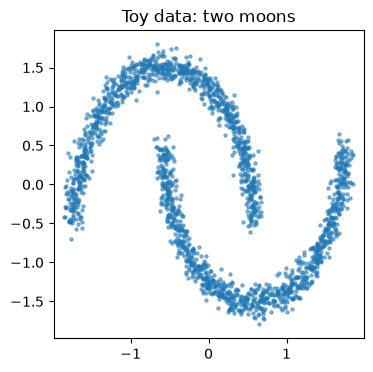

X shape: (2000, 2) mean: [-1.37578837e-15  6.85673740e-16] std: [1. 1.]


In [2]:
# ## 1. Toy 2D dataset ("two moons")
#
# Diffusion models are usually shown on images, but the forward/reverse
# process and the training objective are exactly the same on any
# continuous data - a 2D point cloud makes every step (noising, training,
# sampling) directly plottable. `make_two_moons` (data/toy_datasets.py)
# builds 2 interleaving half-circles and normalizes them to mean 0 / std 1.

import numpy as np
import matplotlib.pyplot as plt

from models.diffusion.model import DDPM
from models.diffusion.train import fit
from data.toy_datasets import make_two_moons

np.random.seed(0)
X = make_two_moons(n_samples=2000, noise=0.05, seed=0)

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.5)
plt.title("Toy data: two moons")
plt.axis("equal")
plt.show()

print("X shape:", X.shape, "mean:", X.mean(axis=0), "std:", X.std(axis=0))

# Toy data cell, explained
#
# The actual output is a scatter plot of 2 interleaving half-moon arcs,
# plus `X shape: (2000, 2)` (2000 points, 2 coordinates each) with mean
# ~[0, 0] and std ~[1, 1] - the normalization makes this data a reasonable
# match for the N(0, I) prior the forward process converges to.

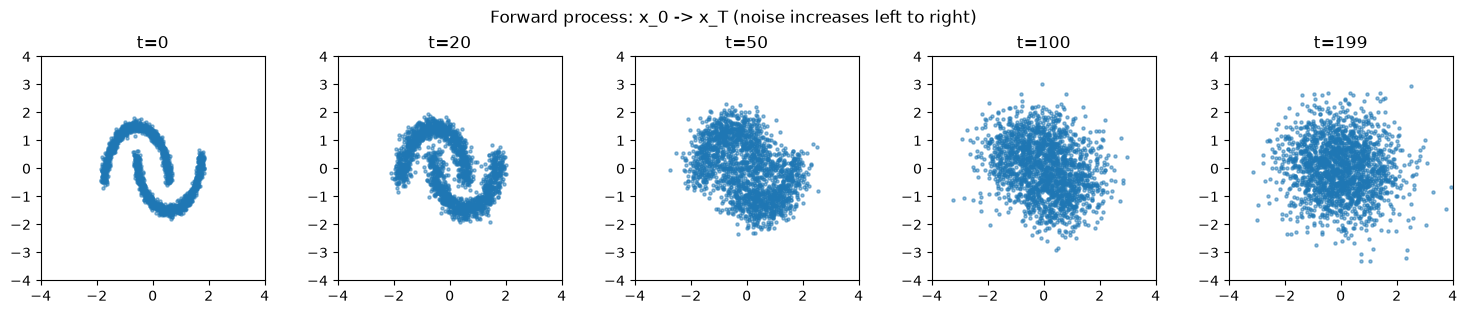

In [3]:
# ## 2. Forward process: q(x_t | x_0)
#
# Build a `DDPM` (only its `DiffusionSchedule` is used in this section -
# the network hasn't been trained yet) and call `q_sample` at increasing
# timesteps to watch the data dissolve into pure Gaussian noise. This is
# the fixed, closed-form process
# `q(x_t | x_0) = N(sqrt(alpha_bar_t) x_0, (1 - alpha_bar_t) I)`
# described in models/diffusion/README.md - no learning involved yet.

model = DDPM(data_dim=2, time_dim=32, hidden_dim=128, timesteps=200)

timesteps_to_show = [0, 20, 50, 100, 199]
fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(3 * len(timesteps_to_show), 3))
for ax, t_val in zip(axes, timesteps_to_show):
    t = np.full(len(X), t_val)
    x_t, _ = model.q_sample(X, t)
    ax.scatter(x_t[:, 0], x_t[:, 1], s=5, alpha=0.5)
    ax.set_title(f"t={t_val}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
plt.suptitle("Forward process: x_0 -> x_T (noise increases left to right)")
plt.tight_layout()
plt.show()

# Forward process cell, explained
#
# The actual output is a row of 5 scatter plots. At `t=0` the two moons
# are still clearly visible (barely any noise mixed in yet); by `t=199`
# (the last step, out of 200 total) the points have spread into a
# featureless, roughly isotropic Gaussian blob - `sqrt(alpha_bar_t)` has
# shrunk close to 0 while `sqrt(1 - alpha_bar_t)` has grown close to 1, so
# `x_t` is almost entirely noise by the end of the schedule.

step     1/4000 | loss = 5.2178


step   500/4000 | loss = 0.5248


step  1000/4000 | loss = 0.4942


step  1500/4000 | loss = 0.5824


step  2000/4000 | loss = 0.5875


step  2500/4000 | loss = 0.5305


step  3000/4000 | loss = 0.5097


step  3500/4000 | loss = 0.5083


step  4000/4000 | loss = 0.4890


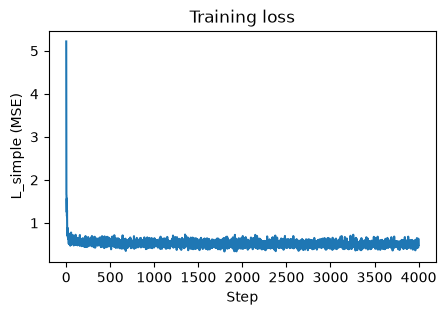

In [4]:
# ## 3. Train the denoiser eps_theta(x_t, t)
#
# `fit` (models/diffusion/train.py) repeatedly samples a random timestep t
# per example, noises x_0 to x_t via `q_sample`, and updates `DenoiserMLP`
# (built from `Linear`/`SiLU`/`sinusoidal_time_embedding`) so its noise
# prediction matches the true eps: `L_simple = MSE(eps_pred, eps)`
# (utils/loss/MSELoss.py), optimized with Adam (utils/optimizers/Adam.py).

history, _ = fit(model, X, n_steps=4000, batch_size=128, lr=2e-3, log_every=500)

plt.figure(figsize=(5, 3))
plt.plot(history)
plt.xlabel("Step")
plt.ylabel("L_simple (MSE)")
plt.title("Training loss")
plt.show()

# Training cell, explained
#
# The actual output is the printed loss every 500 steps (dropping from
# ~5 near step 1 down to under 0.5) plus a loss curve that trends clearly
# downward and flattens out - the denoiser is learning to predict the
# noise `eps` mixed into `x_t` at every timestep, not just a few.

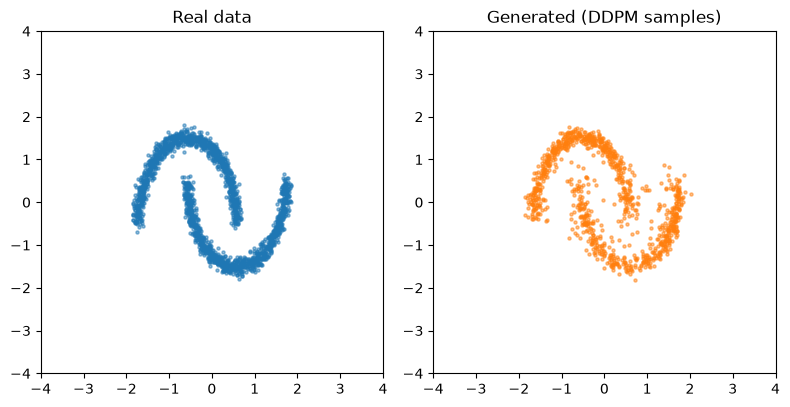

real data      mean/std: [-1.37578837e-15  6.85673740e-16] [1. 1.]
generated data mean/std: [0.02103616 0.15321304] [1.03815938 0.96358528]


In [5]:
# ## 4. Reverse process: sample from pure noise
#
# `DDPM.sample` starts from `x_T ~ N(0, I)` and runs Algorithm 2 of Ho et
# al. 2020: at each step, predict `eps_theta(x_t, t)`, use it to estimate
# the mean of `p_theta(x_{t-1} | x_t)`, and add a bit of fresh noise back
# in (except at the very last step, t=0) - exactly undoing the forward
# process from section 2, one step at a time.

samples, trajectory = model.sample(1000, return_trajectory=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(X[:, 0], X[:, 1], s=5, alpha=0.5, color="tab:blue")
axes[0].set_title("Real data")
axes[1].scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5, color="tab:orange")
axes[1].set_title("Generated (DDPM samples)")
for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print("real data      mean/std:", X.mean(axis=0), X.std(axis=0))
print("generated data mean/std:", samples.mean(axis=0), samples.std(axis=0))

# Real-vs-generated cell, explained
#
# The actual output is 2 side-by-side scatter plots: the real two-moons
# data on the left, and 1000 fresh samples drawn from pure noise by the
# trained model on the right - reading roughly the same two-moons shape
# back out confirms the reverse process learned to invert the forward
# noising process. The printed mean/std of the generated data should be
# close to the real data's (~0 / ~1), even though no real sample was
# copied - every generated point started as independent Gaussian noise.

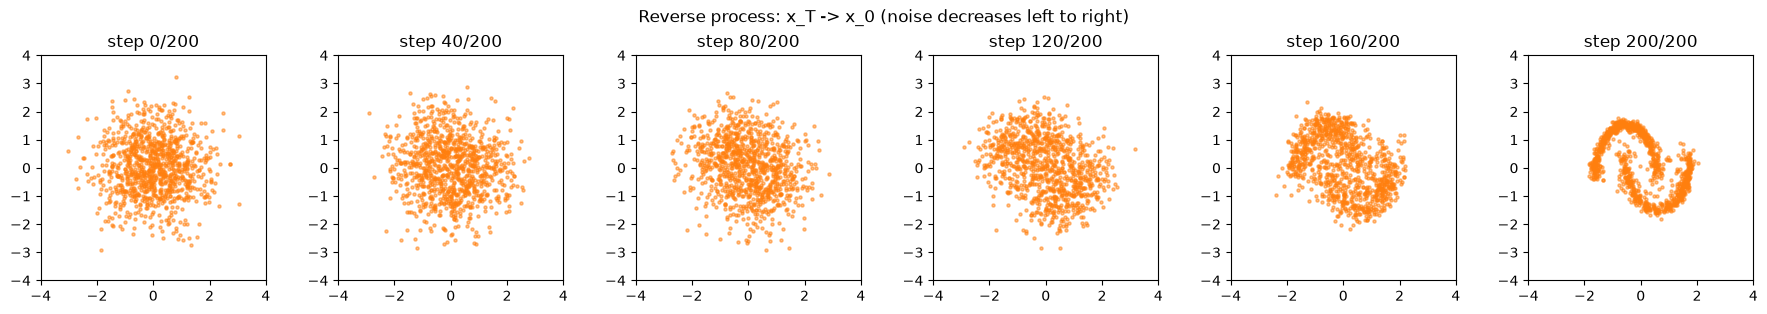

In [6]:
# ## 5. Watch the denoising trajectory
#
# `return_trajectory=True` also returns every intermediate `x_t` from
# `x_T` down to `x_0` (`model.schedule.timesteps + 1` snapshots total) -
# the reverse-process mirror of the forward noising grid in section 2, so
# we can watch the same 1000 points get denoised step by step.

steps_to_show = [0, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(3 * len(steps_to_show), 3))
for ax, step in zip(axes, steps_to_show):
    pts = trajectory[step]
    ax.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.5, color="tab:orange")
    ax.set_title(f"step {step}/{len(trajectory) - 1}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
plt.suptitle("Reverse process: x_T -> x_0 (noise decreases left to right)")
plt.tight_layout()
plt.show()

# Denoising trajectory cell, explained
#
# The actual output is a row of 6 scatter plots going from `step 0`
# (pure Gaussian noise, identical in spirit to `t=199` in section 2) to
# `step 200` (the final generated sample, identical to the right panel in
# section 4). The two-moons structure should emerge gradually across the
# row rather than appearing suddenly at the last step, matching how
# Algorithm 2 removes noise incrementally instead of in one jump.

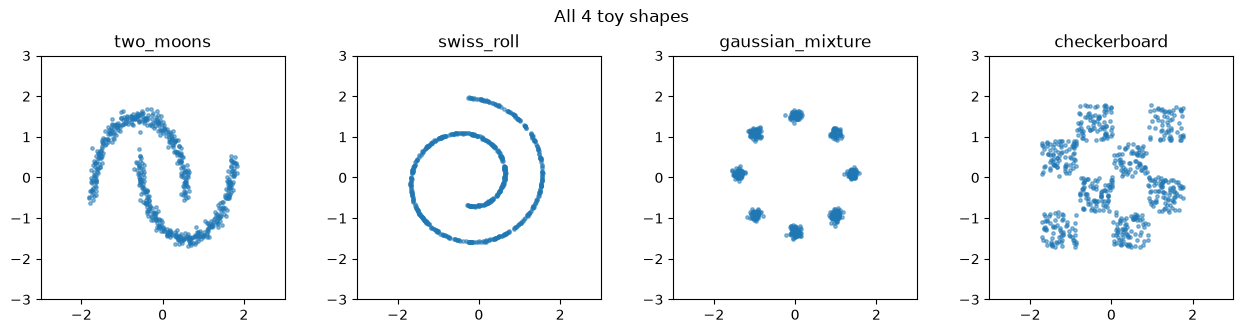

In [7]:
# ## 6. Four toy 2D shapes
#
# Everything so far only used "two moons". `data/toy_datasets.py` has 3
# more generators, all normalized to mean ~0 / std ~1: `make_swiss_roll_2d`,
# `make_gaussian_mixture` (8 blobs on a ring), and `make_checkerboard` (a
# sharply multi-modal grid). `TOY_DATASETS` maps each name to its generator
# function, so the rest of this notebook can loop over "all the shapes we
# have" instead of hardcoding separate calls.

from data.toy_datasets import TOY_DATASETS

N_PER_SHAPE = 600
shapes = {name: fn(n_samples=N_PER_SHAPE, seed=0) for name, fn in TOY_DATASETS.items()}

fig, axes = plt.subplots(1, len(shapes), figsize=(3.2 * len(shapes), 3.2))
for ax, (name, shape_X) in zip(axes, shapes.items()):
    ax.scatter(shape_X[:, 0], shape_X[:, 1], s=6, alpha=0.5)
    ax.set_title(name)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
plt.suptitle("All 4 toy shapes")
plt.tight_layout()
plt.show()

# Four shapes cell, explained
#
# The actual output is a row of 4 scatter plots, one per shape in
# `TOY_DATASETS` - visually confirming each generator produces a distinct,
# recognizable silhouette (2 moons, a spiral, 8 ring blobs, a checkerboard
# grid). The rest of the notebook reuses these exact same `shapes` arrays.

step     1/6000 | loss = 3.8704


step  1000/6000 | loss = 0.5853


step  2000/6000 | loss = 0.5606


step  3000/6000 | loss = 0.5542


step  4000/6000 | loss = 0.5616


step  5000/6000 | loss = 0.6921


step  6000/6000 | loss = 0.5408


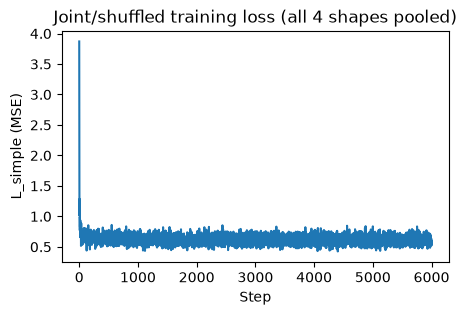

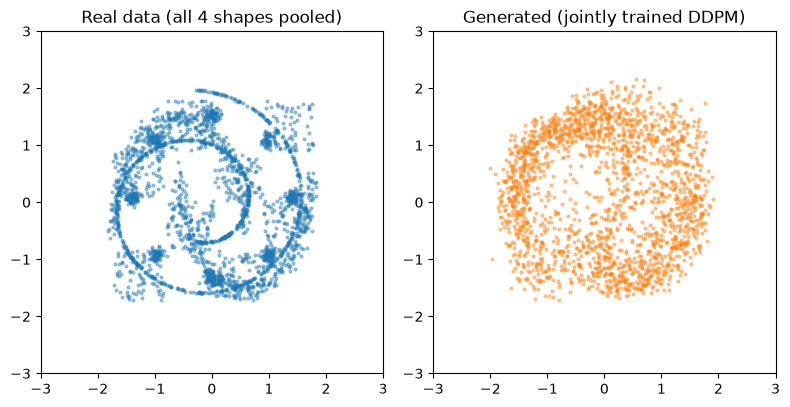

In [8]:
# ## 7. Joint / shuffled training across all shapes
#
# Pool all 4 shapes into one dataset and shuffle the row order. `fit`
# already draws a fresh random minibatch every step via `np.random.randint`,
# so training on this pooled, shuffled array means every step's batch is a
# random mix of all 4 shapes throughout *all* of training - this is the
# baseline we contrast catastrophic forgetting against in section 9.

X_all = np.concatenate(list(shapes.values()), axis=0)
np.random.seed(0)
X_all = X_all[np.random.permutation(len(X_all))]

np.random.seed(0)
joint_model = DDPM(data_dim=2, time_dim=32, hidden_dim=128, timesteps=150)
joint_history, _ = fit(joint_model, X_all, n_steps=6000, batch_size=128, lr=2e-3, log_every=1000)

plt.figure(figsize=(5, 3))
plt.plot(joint_history)
plt.xlabel("Step")
plt.ylabel("L_simple (MSE)")
plt.title("Joint/shuffled training loss (all 4 shapes pooled)")
plt.show()

joint_samples = joint_model.sample(2000)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(X_all[:, 0], X_all[:, 1], s=4, alpha=0.4)
axes[0].set_title("Real data (all 4 shapes pooled)")
axes[1].scatter(joint_samples[:, 0], joint_samples[:, 1], s=4, alpha=0.4, color="tab:orange")
axes[1].set_title("Generated (jointly trained DDPM)")
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Joint training cell, explained
#
# The actual output is a downward-trending loss curve, then 2 side-by-side
# scatter plots. Because every training step saw a random mix of all 4
# shapes, the generated cloud on the right should show traces of all 4
# silhouettes at once (moons, spiral, ring blobs, checkerboard) rather
# than collapsing onto just one - the model never had a chance to "forget"
# any of them since they were all present in every phase of training.

In [9]:
# ## 8. Sequential / continual training - one shape at a time
#
# Now train a *fresh* model the opposite way: instead of pooling and
# shuffling the data, shuffle the *order of the shapes themselves* and
# train on one full shape at a time, continuing the same model weights
# and the same `Adam` optimizer state (`fit(..., optimizer=optimizer)`,
# see models/diffusion/train.py) from one phase to the next. By the last
# phase, the model has not seen a single example of the first shape in
# 3 full training phases - this is the classic continual-learning setup
# that catastrophic forgetting shows up in.

shape_order = list(shapes.keys())
np.random.seed(1)
np.random.shuffle(shape_order)
print("training curriculum order:", shape_order)

np.random.seed(0)
seq_model = DDPM(data_dim=2, time_dim=32, hidden_dim=128, timesteps=150)
optimizer = None
phase_samples = {}   # shape trained in this phase -> samples drawn right after it
phase_histories = {}

for phase_i, name in enumerate(shape_order):
    print(f"--- phase {phase_i + 1}/{len(shape_order)}: training on '{name}' only ---")
    phase_history, optimizer = fit(
        seq_model, shapes[name], n_steps=1500, batch_size=128, lr=2e-3,
        log_every=1500, optimizer=optimizer,
    )
    phase_histories[name] = phase_history
    phase_samples[name] = seq_model.sample(600)

# Sequential training cell, explained
#
# The actual output is the chosen random curriculum order (e.g.
# `['checkerboard', 'gaussian_mixture', 'two_moons', 'swiss_roll']`) plus
# one loss line per phase. `phase_samples[name]` freezes what the model
# could generate *immediately after* finishing training on `name`, before
# moving on to the next shape - section 9 compares these snapshots to see
# how much they degrade once the model moves on.

training curriculum order: ['checkerboard', 'gaussian_mixture', 'two_moons', 'swiss_roll']
--- phase 1/4: training on 'checkerboard' only ---
step     1/1500 | loss = 4.2211


step  1500/1500 | loss = 0.7563


--- phase 2/4: training on 'gaussian_mixture' only ---
step     1/1500 | loss = 0.7140


step  1500/1500 | loss = 0.6113


--- phase 3/4: training on 'two_moons' only ---
step     1/1500 | loss = 0.8859


step  1500/1500 | loss = 0.5926


--- phase 4/4: training on 'swiss_roll' only ---
step     1/1500 | loss = 0.8044


step  1500/1500 | loss = 0.6918


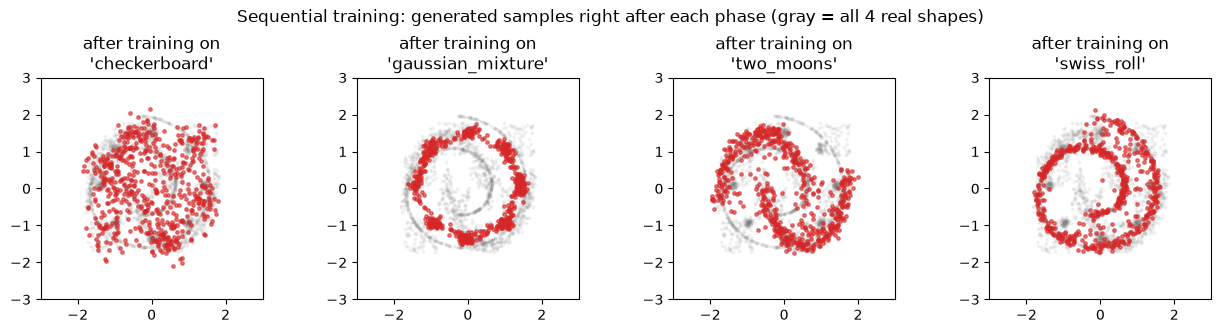

In [10]:
# ## 9. Visualize forgetting: samples right after each phase
#
# For each phase (in training order), plot the samples captured in
# `phase_samples` right after that phase - faded gray points in the
# background show *all 4* real shapes for reference. If earlier shapes
# are being forgotten, later panels should only cover the most recently
# trained shape's region and leave the earlier shapes' regions empty.

fig, axes = plt.subplots(1, len(shape_order), figsize=(3.2 * len(shape_order), 3.2))
for ax, name in zip(axes, shape_order):
    for other_name, other_X in shapes.items():
        ax.scatter(other_X[:, 0], other_X[:, 1], s=3, alpha=0.08, color="gray")
    pts = phase_samples[name]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.6, color="tab:red")
    ax.set_title(f"after training on\n'{name}'")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
plt.suptitle("Sequential training: generated samples right after each phase (gray = all 4 real shapes)")
plt.tight_layout()
plt.show()

# Forgetting visualization cell, explained
#
# The actual output is a row of scatter plots, one per training phase, in
# curriculum order. Each red cloud should closely match the shape *just*
# trained on - not any of the others - since the model was only shown
# that one shape's data during that phase (its weights from the *previous*
# phase's shape are still in there somewhere, but training on new data
# with no rehearsal keeps overwriting them). This is the visual signature
# of catastrophic forgetting: contrast this row against section 7's single
# panel, where the joint/shuffled model covered all 4 shapes at once.

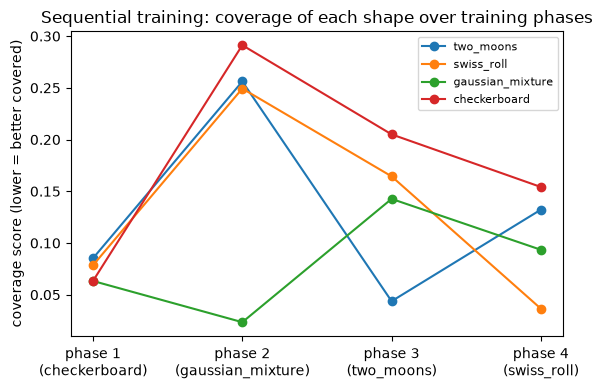

joint/shuffled model coverage score per shape (lower = better):
           two_moons: 0.0362
          swiss_roll: 0.0412
    gaussian_mixture: 0.0350


        checkerboard: 0.0438


In [11]:
# ## 10. Quantify forgetting: nearest-neighbor coverage score
#
# `coverage_score(real, generated)` is the mean distance from every real
# point of a shape to its nearest neighbor in a generated point cloud - a
# simple, dependency-free (pure NumPy) proxy for "does the generated cloud
# still represent this shape". Low score = good coverage (real points have
# a nearby generated point); high score = poor coverage (the shape's
# region is empty in the generated cloud).

def coverage_score(real, generated):
    diffs = real[:, None, :] - generated[None, :, :]
    dists = np.sqrt((diffs ** 2).sum(axis=-1))
    return dists.min(axis=1).mean()

# Sequential model: coverage of EVERY shape, evaluated after EACH phase.
seq_coverage = {name: [] for name in shapes}
for phase_name in shape_order:
    gen = phase_samples[phase_name]
    for eval_name, real_X in shapes.items():
        seq_coverage[eval_name].append(coverage_score(real_X, gen))

plt.figure(figsize=(6, 4))
x_axis = np.arange(1, len(shape_order) + 1)
for name in shapes:
    plt.plot(x_axis, seq_coverage[name], marker="o", label=name)
plt.xticks(x_axis, [f"phase {i}\n({shape_order[i-1]})" for i in x_axis])
plt.ylabel("coverage score (lower = better covered)")
plt.title("Sequential training: coverage of each shape over training phases")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Joint model: coverage of every shape, evaluated once (no phases).
print("joint/shuffled model coverage score per shape (lower = better):")
for name, real_X in shapes.items():
    print(f"  {name:>18s}: {coverage_score(real_X, joint_samples):.4f}")

# Coverage score cell, explained
#
# The actual output is a line chart with 4 lines (one per shape). Each
# shape's line should dip to its lowest point exactly at the phase where
# it was trained, then climb back up in later phases as the model is
# retrained on other shapes with no rehearsal - a numeric confirmation of
# what section 9 showed visually. The printed joint-model scores below it
# should all be low and roughly similar to each other, since that model
# saw every shape throughout the entirety of training instead of in
# separate phases.